In [17]:
import pandas as pd
from tqdm import tqdm
from rdkit import Chem
from rdkit import Chem, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize

RDLogger.DisableLog('rdApp.*')

In [18]:
df_splits_llm = pd.read_csv('../tack_v2_smiles_splits_llm_score.csv')
df_splits_llm_leftover = pd.read_csv('../tack_v2_leftover_llm_score.csv')
df_splits_llm

,SMILES,default_pred_n0,model_name,heuristic_params,n_flags,review_reasons,llm_error,llm_mode,llm_score,llm_score_median,...,llm_confidence,llm_n_samples,llm_risk_factors,llm_rationale,llm_n_building_blocks,llm_resolved_depth,llm_n_steps,llm_mean_step_score,llm_min_step_score,llm_step_scores
0,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1.O=...,XGBoost,NaN,1,poi_low_similarity,NaN,molecule_only,40.000000,45.0,...,58.333333,3.0,"Multiple amide couplings required, leading to ...",This molecule is a complex bifunctional molecu...,0.0,NaN,0.0,NaN,NaN,NaN
1,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCCOCCC(=O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,XGBoost,NaN,0,NaN,NaN,molecule_only,33.333333,25.0,...,70.000000,3.0,Setting and controlling multiple stereocenters...,"The target molecule is a large, complex bifunc...",0.0,NaN,0.0,NaN,NaN,NaN
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NC(=O)CC...,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,NaN,molecule_only,52.666667,55.0,...,75.000000,3.0,Potential epimerization at the N-methyl alanin...,"The target molecule is a large, complex entity...",0.0,NaN,0.0,NaN,NaN,NaN
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,XGBoost,NaN,0,NaN,NaN,molecule_only,45.000000,45.0,...,70.000000,3.0,Synthesis of the fused heterocyclic core: This...,The target molecule is a complex structure wit...,0.0,NaN,0.0,NaN,NaN,NaN
4,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.C(C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",0,NaN,NaN,molecule_only,55.000000,55.0,...,80.000000,3.0,Synthesis of the substituted pyridinone core.;...,The molecule is a PROTAC-like bifunctional com...,0.0,NaN,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,O=C1CCN(c2ccc3c(c2)OC[C@H]2CN([*:2])CCN32)C(=O...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,litellm.APIError: APIError: OpenrouterExceptio...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4154,O=C1CCC(Nc2ccc(N3CCN(C4CCN(c5ccc6c(c5)n(C5CCCC...,O=C1CCC(Nc2ccc(N3CCN([*:2])CC3)c(F)c2)C(=O)N1....,XGBoost,NaN,1,poi_low_similarity,litellm.APIError: APIError: OpenrouterExceptio...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4155,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,O=C1CCC(N2C(=O)c3ccc([*:2])cc3C2=O)C(=O)N1.C1C...,XGBoost,NaN,0,NaN,litellm.APIError: APIError: OpenrouterExceptio...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4156,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,e3_low_similarity,litellm.APIError: APIError: OpenrouterExceptio...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
error_mask = df_splits_llm['llm_error'].notna()

df_splits_llm_indexed = df_splits_llm.set_index('SMILES')
df_leftover_indexed = df_splits_llm_leftover.set_index('SMILES')

# Only refresh the rows that originally errored; leave everything else untouched
error_rows = df_splits_llm_indexed.loc[error_mask.values].copy()
error_rows.update(df_leftover_indexed)

# update() skips NaN values in the source, but a resolved retry has llm_error == NaN
# (success) — that NaN must still overwrite the old error string, so set it explicitly
matched = error_rows.index.intersection(df_leftover_indexed.index)
error_rows.loc[matched, 'llm_error'] = df_leftover_indexed.loc[matched, 'llm_error']

df_splits_llm_indexed.loc[error_mask.values] = error_rows
df_splits_llm = df_splits_llm_indexed.reset_index()
print(df_splits_llm['llm_error'].value_counts(dropna=False))
df_splits_llm

llm_error
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

,SMILES,default_pred_n0,model_name,heuristic_params,n_flags,review_reasons,llm_error,llm_mode,llm_score,llm_score_median,...,llm_confidence,llm_n_samples,llm_risk_factors,llm_rationale,llm_n_building_blocks,llm_resolved_depth,llm_n_steps,llm_mean_step_score,llm_min_step_score,llm_step_scores
0,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1.O=...,XGBoost,NaN,1,poi_low_similarity,NaN,molecule_only,40.000000,45.0,...,58.333333,3.0,"Multiple amide couplings required, leading to ...",This molecule is a complex bifunctional molecu...,0.0,NaN,0.0,NaN,NaN,NaN
1,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCCOCCC(=O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,XGBoost,NaN,0,NaN,NaN,molecule_only,33.333333,25.0,...,70.000000,3.0,Setting and controlling multiple stereocenters...,"The target molecule is a large, complex bifunc...",0.0,NaN,0.0,NaN,NaN,NaN
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NC(=O)CC...,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,NaN,molecule_only,52.666667,55.0,...,75.000000,3.0,Potential epimerization at the N-methyl alanin...,"The target molecule is a large, complex entity...",0.0,NaN,0.0,NaN,NaN,NaN
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,XGBoost,NaN,0,NaN,NaN,molecule_only,45.000000,45.0,...,70.000000,3.0,Synthesis of the fused heterocyclic core: This...,The target molecule is a complex structure wit...,0.0,NaN,0.0,NaN,NaN,NaN
4,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.C(C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",0,NaN,NaN,molecule_only,55.000000,55.0,...,80.000000,3.0,Synthesis of the substituted pyridinone core.;...,The molecule is a PROTAC-like bifunctional com...,0.0,NaN,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,O=C1CCN(c2ccc3c(c2)OC[C@H]2CN([*:2])CCN32)C(=O...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,NaN,molecule_only,55.000000,55.0,...,80.000000,3.0,Epimerization of the glutarimide under basic o...,"The molecule is a complex, multi-component str...",0.0,NaN,0.0,NaN,NaN,NaN
4154,O=C1CCC(Nc2ccc(N3CCN(C4CCN(c5ccc6c(c5)n(C5CCCC...,O=C1CCC(Nc2ccc(N3CCN([*:2])CC3)c(F)c2)C(=O)N1....,XGBoost,NaN,1,poi_low_similarity,NaN,molecule_only,50.000000,50.0,...,80.000000,2.0,Glutarimide epimerization/hydrolysis under cou...,The molecule is a complex bifunctional compoun...,0.0,NaN,0.0,NaN,NaN,NaN
4155,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,O=C1CCC(N2C(=O)c3ccc([*:2])cc3C2=O)C(=O)N1.C1C...,XGBoost,NaN,0,NaN,NaN,molecule_only,55.000000,55.0,...,75.000000,2.0,Stereochemical control within the fused bicycl...,"The molecule presents a complex, fused polycyc...",0.0,NaN,0.0,NaN,NaN,NaN
4156,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,e3_low_similarity,NaN,molecule_only,66.666667,65.0,...,80.000000,3.0,Potential epimerization or degradation of the ...,The target molecule is a PROTAC-like structure...,0.0,NaN,0.0,NaN,NaN,NaN


In [20]:
df_scores = pd.read_csv('../tack_v2_scores.csv')
df_scores = df_scores.rename(columns={'molecule': 'SMILES'})
df_scores

,SMILES,sa_score,sa_score_scaled,sc_score,sc_score_scaled,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,fs_score,fs_score_scaled
0,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,6.721362,0.364293,4.999999,2.237609e-07,0.079354,211.568173,1.0,0,0.740784,-30.843750,0.043756
1,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCCOCCC(=O...,5.739190,0.473423,5.000000,8.126953e-08,0.234662,120.899893,1.0,0,0.501147,-37.000000,0.024127
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NC(=O)CC...,5.727850,0.474683,5.000000,0.000000e+00,0.678172,264.350206,1.0,0,0.971818,-41.875000,0.014957
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,5.328788,0.519024,5.000000,3.128164e-12,0.159609,119.883007,1.0,1,0.212970,-29.484375,0.049810
4,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,4.662556,0.593049,5.000000,2.548216e-08,0.394393,136.611543,1.0,0,0.923146,-27.078125,0.062514
...,...,...,...,...,...,...,...,...,...,...,...,...
4153,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,4.900241,0.566640,5.000000,0.000000e+00,0.152777,37.689949,1.0,0,0.899432,-32.968750,0.035679
4154,O=C1CCC(Nc2ccc(N3CCN(C4CCN(c5ccc6c(c5)n(C5CCCC...,3.867817,0.681354,4.999087,2.282213e-04,0.767574,84.004101,1.0,1,0.402115,-25.312500,0.073696
4155,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,4.462346,0.615295,4.999824,4.401421e-05,0.407039,35.225586,1.0,0,0.605042,-28.093750,0.056820
4156,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,4.409887,0.621124,4.999975,6.332987e-06,0.123726,98.649445,1.0,1,0.330919,-30.125000,0.046864


In [21]:
df = pd.merge(df_splits_llm, df_scores, on='SMILES')
df

,SMILES,default_pred_n0,model_name,heuristic_params,n_flags,review_reasons,llm_error,llm_mode,llm_score,llm_score_median,...,sa_score_scaled,sc_score,sc_score_scaled,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,fs_score,fs_score_scaled
0,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1.O=...,XGBoost,NaN,1,poi_low_similarity,NaN,molecule_only,40.000000,45.0,...,0.364293,4.999999,2.237609e-07,0.079354,211.568173,1.0,0,0.740784,-30.843750,0.043756
1,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCCOCCC(=O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,XGBoost,NaN,0,NaN,NaN,molecule_only,33.333333,25.0,...,0.473423,5.000000,8.126953e-08,0.234662,120.899893,1.0,0,0.501147,-37.000000,0.024127
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NC(=O)CC...,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,NaN,molecule_only,52.666667,55.0,...,0.474683,5.000000,0.000000e+00,0.678172,264.350206,1.0,0,0.971818,-41.875000,0.014957
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,XGBoost,NaN,0,NaN,NaN,molecule_only,45.000000,45.0,...,0.519024,5.000000,3.128164e-12,0.159609,119.883007,1.0,1,0.212970,-29.484375,0.049810
4,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.C(C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",0,NaN,NaN,molecule_only,55.000000,55.0,...,0.593049,5.000000,2.548216e-08,0.394393,136.611543,1.0,0,0.923146,-27.078125,0.062514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,O=C1CCN(c2ccc3c(c2)OC[C@H]2CN([*:2])CCN32)C(=O...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,NaN,molecule_only,55.000000,55.0,...,0.566640,5.000000,0.000000e+00,0.152777,37.689949,1.0,0,0.899432,-32.968750,0.035679
4154,O=C1CCC(Nc2ccc(N3CCN(C4CCN(c5ccc6c(c5)n(C5CCCC...,O=C1CCC(Nc2ccc(N3CCN([*:2])CC3)c(F)c2)C(=O)N1....,XGBoost,NaN,1,poi_low_similarity,NaN,molecule_only,50.000000,50.0,...,0.681354,4.999087,2.282213e-04,0.767574,84.004101,1.0,1,0.402115,-25.312500,0.073696
4155,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,O=C1CCC(N2C(=O)c3ccc([*:2])cc3C2=O)C(=O)N1.C1C...,XGBoost,NaN,0,NaN,NaN,molecule_only,55.000000,55.0,...,0.615295,4.999824,4.401421e-05,0.407039,35.225586,1.0,0,0.605042,-28.093750,0.056820
4156,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,e3_low_similarity,NaN,molecule_only,66.666667,65.0,...,0.621124,4.999975,6.332987e-06,0.123726,98.649445,1.0,1,0.330919,-30.125000,0.046864


In [22]:
def canonicalize_smiles(smiles: str, unique_inchikeys = None):
    """ Convert a SMILES string to its canonical form using RDKit.
    
    Args:
        smiles (str): The input SMILES string to canonicalize.
        unique_inchikeys (dict, optional): A dictionary to track unique InChI.
            If provided, the function will return None for any molecule whose
            InChIKey is already in the dictionary, effectively filtering out
            duplicates. The dictionary is updated with new InChIKeys for unique
            molecules.
            
    Returns:
        str or None: The canonical SMILES string, or None if invalid or duplicate.
    """
    if pd.isna(smiles) or not smiles:
        return None

    mol = Chem.MolFromSmiles(str(smiles), sanitize=False)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None

    try:
        # Keep only the largest fragment (i.e., remove salts)
        mol = rdMolStandardize.FragmentParent(mol)
        
        # Uncharge the molecule (i.e., remove formal charges)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)

        if unique_inchikeys is not None:
            inchikey = Chem.MolToInchiKey(mol)
            if inchikey in unique_inchikeys:
                return None
            unique_inchikeys[inchikey] = mol

        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return None

def split_pred(row):
    smi = row['default_pred_n0']
    splits = {}
    for component in smi.split('.'):
        if '[*:1]' in component and '[*:2]' in component:
            splits['linker'] = canonicalize_smiles(component)
        elif '[*:1]' in component and '[*:2]' not in component:
            splits['wh'] = canonicalize_smiles(component)
        elif '[*:1]' not in component and '[*:2]' in component:
            splits['e3'] = canonicalize_smiles(component)
    row['SMILES'] = canonicalize_smiles(row['SMILES'])
    row['SMILES_Warhead'] = splits['wh']
    row['SMILES_Linker'] = splits['linker']
    row['SMILES_Recruiter_Ligand'] = splits['e3']
    return row

tqdm.pandas(desc='Split predictions')
df = df.progress_apply(split_pred, axis=1)
df = df.rename(columns={
    'model_name': 'PROTAC-Splitter_Model',
    'n_flags': 'PROTAC-Splitter_Number_of_Warnings',
    'review_reasons': 'PROTAC-Splitter_Warnings'
})
df

Split predictions: 100%|██████████| 4158/4158 [00:26<00:00, 157.28it/s]


,SMILES,default_pred_n0,PROTAC-Splitter_Model,heuristic_params,PROTAC-Splitter_Number_of_Warnings,PROTAC-Splitter_Warnings,llm_error,llm_mode,llm_score,llm_score_median,...,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,fs_score,fs_score_scaled,SMILES_Warhead,SMILES_Linker,SMILES_Recruiter_Ligand
0,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1.O=...,XGBoost,NaN,1,poi_low_similarity,NaN,molecule_only,40.000000,45.0,...,0.079354,211.568173,1.0,0,0.740784,-30.843750,0.043756,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,O=C(CCCCCn1cc(COCCOCCOCCN[*:1])nn1)[*:2],O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1
1,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCCOCCC(=O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,XGBoost,NaN,0,NaN,NaN,molecule_only,33.333333,25.0,...,0.234662,120.899893,1.0,0,0.501147,-37.000000,0.024127,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3C[*:1])nc3...,O=C(CCOCC[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NC(=O)CC...,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,NaN,molecule_only,52.666667,55.0,...,0.678172,264.350206,1.0,0,0.971818,-41.875000,0.014957,COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5...,O=C(CCCCCCCCCN1CCN(CCCO[*:1])CC1)[*:2],CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,XGBoost,NaN,0,NaN,NaN,molecule_only,45.000000,45.0,...,0.159609,119.883007,1.0,1,0.212970,-29.484375,0.049810,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)[*:1...,O=C(COCCOCCOCCN[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...
4,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.C(C...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",0,NaN,NaN,molecule_only,55.000000,55.0,...,0.394393,136.611543,1.0,0,0.923146,-27.078125,0.062514,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,C(COCCOCCOCCOCCOCCO[*:1])N[*:2],O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,O=C1CCN(c2ccc3c(c2)OC[C@H]2CN([*:2])CCN32)C(=O...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,poi_low_similarity,NaN,molecule_only,55.000000,55.0,...,0.152777,37.689949,1.0,0,0.899432,-32.968750,0.035679,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,O=C(C[*:2])[*:1],O=C1CCN(c2ccc3c(c2)OC[C@H]2CN([*:2])CCN32)C(=O)N1
4154,O=C1CCC(Nc2ccc(N3CCN(C4CCN(c5ccc6c(c5)n(C5CCCC...,O=C1CCC(Nc2ccc(N3CCN([*:2])CC3)c(F)c2)C(=O)N1....,XGBoost,NaN,1,poi_low_similarity,NaN,molecule_only,50.000000,50.0,...,0.767574,84.004101,1.0,1,0.402115,-25.312500,0.073696,O=c1nc2n(C3CCCC3)c3cc([*:1])ccc3n2c2cccc(Cl)c12,C1CN([*:1])CCC1[*:2],O=C1CCC(Nc2ccc(N3CCN([*:2])CC3)c(F)c2)C(=O)N1
4155,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,O=C1CCC(N2C(=O)c3ccc([*:2])cc3C2=O)C(=O)N1.C1C...,XGBoost,NaN,0,NaN,NaN,molecule_only,55.000000,55.0,...,0.407039,35.225586,1.0,0,0.605042,-28.093750,0.056820,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,C1C([*:1])CN1[*:2],O=C1CCC(N2C(=O)c3ccc([*:2])cc3C2=O)C(=O)N1
4156,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...,Heuristic,"betweenness_threshold=0.4,use_capacity_weight=...",1,e3_low_similarity,NaN,molecule_only,66.666667,65.0,...,0.123726,98.649445,1.0,1,0.330919,-30.125000,0.046864,COc1cc(O[C@H]2C(C)(C)[C@H](N[*:1])C2(C)C)ccc1C#N,O=C(c1ccc(N2CCC(C[*:2])CC2)cc1)[*:1],O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...


In [23]:
df['llm_score'].isna().sum() / len(df)

0.012506012506012507

In [24]:
df.drop(columns=['heuristic_params', 'default_pred_n0'])

,SMILES,PROTAC-Splitter_Model,PROTAC-Splitter_Number_of_Warnings,PROTAC-Splitter_Warnings,llm_error,llm_mode,llm_score,llm_score_median,llm_score_std,llm_category,...,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,fs_score,fs_score_scaled,SMILES_Warhead,SMILES_Linker,SMILES_Recruiter_Ligand
0,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,XGBoost,1,poi_low_similarity,NaN,molecule_only,40.000000,45.0,14.719601,Challenging but feasible (multi-step / sensiti...,...,0.079354,211.568173,1.0,0,0.740784,-30.843750,0.043756,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,O=C(CCCCCn1cc(COCCOCCOCCN[*:1])nn1)[*:2],O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1
1,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCCOCCC(=O...,XGBoost,0,NaN,NaN,molecule_only,33.333333,25.0,15.456031,Very challenging (long sequence / difficult se...,...,0.234662,120.899893,1.0,0,0.501147,-37.000000,0.024127,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3C[*:1])nc3...,O=C(CCOCC[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...
2,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NC(=O)CC...,Heuristic,1,poi_low_similarity,NaN,molecule_only,52.666667,55.0,5.557777,Challenging but feasible (multi-step / sensiti...,...,0.678172,264.350206,1.0,0,0.971818,-41.875000,0.014957,COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5...,O=C(CCCCCCCCCN1CCN(CCCO[*:1])CC1)[*:2],CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...
3,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,XGBoost,0,NaN,NaN,molecule_only,45.000000,45.0,8.164966,Challenging but feasible (multi-step / sensiti...,...,0.159609,119.883007,1.0,1,0.212970,-29.484375,0.049810,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)[*:1...,O=C(COCCOCCOCCN[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...
4,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,Heuristic,0,NaN,NaN,molecule_only,55.000000,55.0,0.000000,Challenging but feasible (multi-step / sensiti...,...,0.394393,136.611543,1.0,0,0.923146,-27.078125,0.062514,NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CC...,C(COCCOCCOCCOCCOCCO[*:1])N[*:2],O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4153,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,Heuristic,1,poi_low_similarity,NaN,molecule_only,55.000000,55.0,0.000000,Challenging but feasible (multi-step / sensiti...,...,0.152777,37.689949,1.0,0,0.899432,-32.968750,0.035679,CNc1cc(-n2ccc3cc(C#N)cnc32)ncc1-c1nnc(C2CC3(CC...,O=C(C[*:2])[*:1],O=C1CCN(c2ccc3c(c2)OC[C@H]2CN([*:2])CCN32)C(=O)N1
4154,O=C1CCC(Nc2ccc(N3CCN(C4CCN(c5ccc6c(c5)n(C5CCCC...,XGBoost,1,poi_low_similarity,NaN,molecule_only,50.000000,50.0,5.000000,Challenging but feasible (multi-step / sensiti...,...,0.767574,84.004101,1.0,1,0.402115,-25.312500,0.073696,O=c1nc2n(C3CCCC3)c3cc([*:1])ccc3n2c2cccc(Cl)c12,C1CN([*:1])CCC1[*:2],O=C1CCC(Nc2ccc(N3CCN([*:2])CC3)c(F)c2)C(=O)N1
4155,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,XGBoost,0,NaN,NaN,molecule_only,55.000000,55.0,0.000000,Challenging but feasible (multi-step / sensiti...,...,0.407039,35.225586,1.0,0,0.605042,-28.093750,0.056820,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,C1C([*:1])CN1[*:2],O=C1CCC(N2C(=O)c3ccc([*:2])cc3C2=O)C(=O)N1
4156,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,Heuristic,1,e3_low_similarity,NaN,molecule_only,66.666667,65.0,6.236096,Challenging but feasible (multi-step / sensiti...,...,0.123726,98.649445,1.0,1,0.330919,-30.125000,0.046864,COc1cc(O[C@H]2C(C)(C)[C@H](N[*:1])C2(C)C)ccc1C#N,O=C(c1ccc(N2CCC(C[*:2])CC2)cc1)[*:1],O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...


In [25]:
df.to_csv('../tack_v2_smiles_split_llm_chem_scores.csv', index=False)
tack_scores = df

In [26]:
tack = pd.read_csv('../tack_v2.csv')
tack_w_preds = pd.read_csv('../tack_v2_with_predictions.csv')
print(tack.columns)
print(tack_w_preds.columns)
tack_w_preds = tack_w_preds.rename(columns={
    'POI_Name': 'Degradation_Target',
    'Ligase_Name': 'Recruiter',
    'Ligase_Sequence': 'Recruiter_Sequence',
})
print(tack_w_preds.columns)

Index(['Reference', 'SMILES', 'Degradation_Target', 'Degradation_Target_Gene',
       'Degradation_Target_Uniprot', 'Degradation_Target_Uniprot_MutationID',
       'Degradation_Target_Sequence', 'Recruiter', 'Recruiter_Gene',
       'Recruiter_Uniprot', 'Recruiter_Sequence', 'Assay', 'Cell_Line',
       'Cell_Line_ID', 'Cell_Line_Species', 'DC50', 'DC50_units', 'DC50_h',
       'DC50_operator', 'DC50_Range_Min', 'DC50_Range_Max', 'Dmax', 'Dmax_h',
       'Dmax_operator', 'Dmax_Range_Min', 'Dmax_Range_Max', 'Dmax_conc',
       'Dmax_conc_operator', 'Dmax_conc_Range_Min', 'Dmax_conc_Range_Max',
       'Dmax_conc_units', 'Database'],
      dtype='object')
Index(['Reference', 'SMILES', 'Degradation_Target', 'Degradation_Target_Gene',
       'Degradation_Target_Uniprot', 'Degradation_Target_Uniprot_MutationID',
       'POI_Sequence', 'Recruiter', 'Recruiter_Gene', 'Recruiter_Uniprot',
       'Recruiter_Sequence', 'Assay', 'Cell_Line', 'Cell_Line_ID',
       'Cell_Line_Species', 'DC50', 'DC5

In [27]:
tqdm.pandas(desc='canonize')
tack_w_preds['SMILES'] = tack_w_preds['SMILES'].progress_apply(canonicalize_smiles)

canonize:   1%|          | 51/6214 [00:00<00:12, 508.12it/s]

canonize: 100%|██████████| 6214/6214 [00:11<00:00, 520.28it/s]


In [28]:
tack_w_preds.to_csv('../tack_v2_with_predictions.csv', index=False)

In [31]:
tack_w_preds_w_scores = pd.merge(tack_w_preds, tack_scores, how='left', on='SMILES').drop(columns=['heuristic_params'])
tack_w_preds_w_scores.to_csv('../tack_v2_with_predictions_scores_splits.csv', index=False)
tack_w_preds_w_scores

,Reference,SMILES,Degradation_Target,Degradation_Target_Gene,Degradation_Target_Uniprot,Degradation_Target_Uniprot_MutationID,POI_Sequence,Recruiter,Recruiter_Gene,Recruiter_Uniprot,...,ra_score,syba_score,syba_score_scaled,gasa_pred,gasa_es_prob,fs_score,fs_score_scaled,SMILES_Warhead,SMILES_Linker,SMILES_Recruiter_Ligand
0,https://pubmed.ncbi.nlm.nih.gov/31512882/,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,NTRK3,NTRK3,Q16288,NaN,MDVSLCPAKCSFWRIFLLGSVWLDYVGSVLACPANCVCSKTEINCR...,CRBN,CRBN,Q96SW2,...,0.079354,211.568173,1.0,0,0.740784,-30.843750,0.043756,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,O=C(CCCCCn1cc(COCCOCCOCCN[*:1])nn1)[*:2],O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1
1,https://pubmed.ncbi.nlm.nih.gov/32875077/,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCCOCCC(=O...,KRAS,KRAS,P01116,NaN,MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVI...,VHL,VHL,P40337,...,0.234662,120.899893,1.0,0,0.501147,-37.000000,0.024127,C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3C[*:1])nc3...,O=C(CCOCC[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...
2,https://pubmed.ncbi.nlm.nih.gov/32001089/,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NC(=O)CC...,JAK1,JAK1,P23458,NaN,MQYLNIKEDCNAMAFCAKMRSSKKTEVNLEAPEPGVEVIFYLSDRE...,IAP,BIRC2,Q13490,...,0.678172,264.350206,1.0,0,0.971818,-41.875000,0.014957,COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5...,O=C(CCCCCCCCCN1CCN(CCCO[*:1])CC1)[*:2],CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...
3,https://pubmed.ncbi.nlm.nih.gov/29949369/,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,BRD4,BRD4,O60885,NaN,MSAESGPGTRLRNLPVMGDGLETSQMSTTQAQAQPQPANAASTNPP...,VHL,VHL,P40337,...,0.159609,119.883007,1.0,1,0.212970,-29.484375,0.049810,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)[*:1...,O=C(COCCOCCOCCN[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...
4,https://pubmed.ncbi.nlm.nih.gov/29949369/,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...,BRD4,BRD4,O60885,NaN,MSAESGPGTRLRNLPVMGDGLETSQMSTTQAQAQPQPANAASTNPP...,VHL,VHL,P40337,...,0.159609,119.883007,1.0,1,0.212970,-29.484375,0.049810,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)[*:1...,O=C(COCCOCCOCCN[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2[C@@H](F)[C@@H](O...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6209,BRUTON'S TYROSINE KINASE DEGRADER CONTAINING F...,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,BTK,BTK,Q06187,NaN,MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFER...,CRBN,CRBN,Q96SW2,...,0.407039,35.225586,1.0,0,0.605042,-28.093750,0.056820,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@H]1C[C@...,C1C([*:1])CN1[*:2],O=C1CCC(N2C(=O)c3ccc([*:2])cc3C2=O)C(=O)N1
6210,CEREBELLAR PROTEIN E3 UBIQUITIN LIGASE INHIBIT...,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,AR,AR,P10275,NaN,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,CRBN,CRBN,Q96SW2,...,0.123726,98.649445,1.0,1,0.330919,-30.125000,0.046864,COc1cc(O[C@H]2C(C)(C)[C@H](N[*:1])C2(C)C)ccc1C#N,O=C(c1ccc(N2CCC(C[*:2])CC2)cc1)[*:1],O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...
6211,CEREBELLAR PROTEIN E3 UBIQUITIN LIGASE INHIBIT...,COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(C...,AR,AR,P10275,NaN,MEVQLGLGRVYPRPPSKTYRGAFQNLFQSVREVIQNPGPRHPEAAS...,CRBN,CRBN,Q96SW2,...,0.123726,98.649445,1.0,1,0.330919,-30.125000,0.046864,COc1cc(O[C@H]2C(C)(C)[C@H](N[*:1])C2(C)C)ccc1C#N,O=C(c1ccc(N2CCC(C[*:2])CC2)cc1)[*:1],O=C1CC[C@H](NC(=O)c2ccc3c(c2)OC[C@@H]2CN([*:2]...
6212,ALLOSTERIC BCR-ABL PROTEOLYSIS TARGETING CHIME...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,BCR/ABL,Abl1,P00520,NaN,MLEICLKLVGCKSKKGLSSSSSCYLEEALQRPVASDFEPQGLSEAA...,VHL,Vhl,P40338,...,0.610795,260.524490,1.0,0,0.997823,-26.531250,0.065797,FC(F)(F)Oc1ccc(Nc2cc(-c3ccc([*:1])cc3)ncn2)cc1,O=C(COCCO[*:1])[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...


In [33]:
tack_w_preds_w_scores.columns

Index(['Reference', 'SMILES', 'Degradation_Target', 'Degradation_Target_Gene',
       'Degradation_Target_Uniprot', 'Degradation_Target_Uniprot_MutationID',
       'POI_Sequence', 'Recruiter', 'Recruiter_Gene', 'Recruiter_Uniprot',
       'Recruiter_Sequence', 'Assay', 'Cell_Line', 'Cell_Line_ID',
       'Cell_Line_Species', 'DC50', 'DC50_units', 'DC50_h', 'DC50_operator',
       'DC50_Range_Min', 'DC50_Range_Max', 'Dmax', 'Dmax_h', 'Dmax_operator',
       'Dmax_Range_Min', 'Dmax_Range_Max', 'Dmax_conc', 'Dmax_conc_operator',
       'Dmax_conc_Range_Min', 'Dmax_conc_Range_Max', 'Dmax_conc_units',
       'Database', 'Assay_Time', 'Dmax_prediction', 'Dmax_uncertainty',
       'Dmax_ci_lower_95', 'Dmax_ci_upper_95', 'DC50_prediction',
       'DC50_uncertainty', 'DC50_ci_lower_95', 'DC50_ci_upper_95',
       'Binary_prediction', 'Binary_uncertainty', 'Binary_ci_lower_95',
       'Binary_ci_upper_95', 'default_pred_n0', 'PROTAC-Splitter_Model',
       'PROTAC-Splitter_Number_of_Warnings', '

In [32]:
tack_w_preds_w_scores['PROTAC-Splitter_Warnings'].value_counts()

PROTAC-Splitter_Warnings
poi_low_similarity                                                       3268
linker_branchy;poi_low_similarity                                         314
linker_branchy                                                            289
e3_low_similarity                                                         204
e3_low_similarity;poi_low_similarity                                      114
poi_out_of_range;linker_branchy                                            55
linker_too_short;poi_low_similarity                                        34
poi_linker_leak;poi_low_similarity                                         16
poi_out_of_range                                                           14
e3_out_of_range;poi_low_similarity                                         13
linker_too_short;e3_low_similarity;poi_low_similarity                       9
poi_linker_leak;linker_branchy;poi_low_similarity                           8
poi_out_of_range;poi_low_similarity    

In [34]:
tack_w_preds_w_scores['PROTAC-Splitter_Number_of_Warnings'].value_counts()

PROTAC-Splitter_Number_of_Warnings
1    3781
0    1825
2     572
3      28
4       8
Name: count, dtype: int64

Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2[C@@H]1CCCN(C(=O)c2cn(CCOCCOCCOCCCc3cccc4c3CN(C3CCC(=O)NC3=O)C4=O)nn2)C1


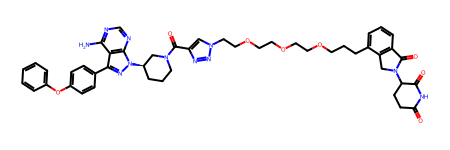

NC(=O)c1c(-c2ccc(Oc3ccccc3)cc2)nn2c1NCC[C@H]2C1CCN(C(=O)CCCc2cn(CCCCNC(=O)COc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)nn2)CC1


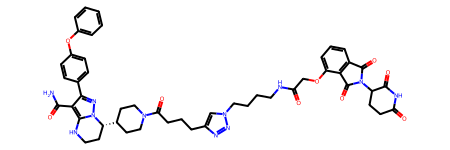

Cc1nc2c(F)cc(-c3nc(Nc4ccc(CN5CCN(c6cn(CCOCCOCCOCCOCCNc7cccc8c7C(=O)N(C7CCC(=O)NC7=O)C8=O)nn6)CC5)cn4)ncc3F)cc2n1C(C)C


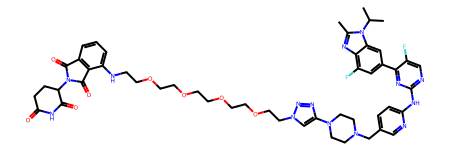

Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)NCCCCCCN1CCC(c3ccc4c(c3)CN(C3CCC(=O)NC3=O)C4=O)CC1)c1nnc(C)n1-2


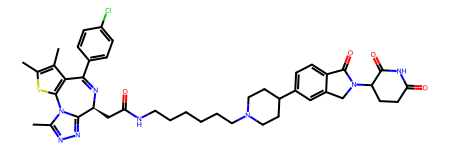

COc1cc(C2CCN(CC3CN(c4ccc5c(c4)C(=O)N(C4CCC(=O)NC4=O)C5=O)C3)CC2)c(C)cc1Nc1ncc(Cl)c(Nc2ccccc2S(=O)(=O)C(C)C)n1


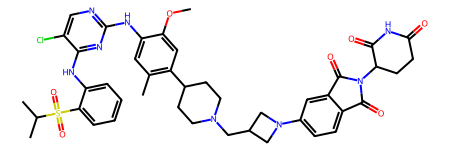

COc1cc(N2CCC(N3CCN(CC4CN(c5cc(F)c(C6CCC(=O)NC6=O)c(F)c5)C4)CC3)CC2)c(C)cc1Nc1ncc(Br)c(Nc2cccc3c2N(S(C)(=O)=O)CC3)n1


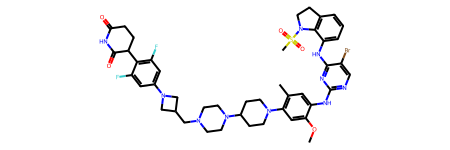

C=C(F)C(=O)N1CCN(c2nc(OC[C@@H]3CCCN3CCC(=O)NCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)nc3c2CCN(c2cccc4cccc(Cl)c24)C3)C[C@@H]1CC#N


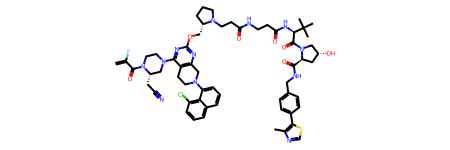

Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCN(Cc2ccc(C#CC3CCN(c4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)CC3)nc2)CC1


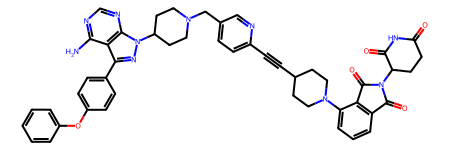

COc1cc(O[C@H]2C(C)(C)[C@H](NC(=O)c3ccc(N4CCC(CN5CCC6(CC5)COc5c6ccc6c5n(C)c(=O)n6C5CCC(=O)NC5=O)CC4)cc3)C2(C)C)ccc1C#N


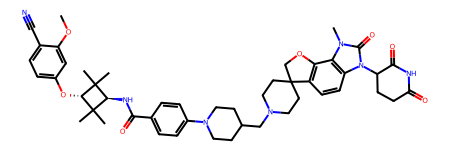

NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN(C(=O)N3CCC(CCC#Cc4cccc5c4CN(C4CCC(=O)NC4=O)C5=O)CC3)C[C@H](NC(=O)c3cc4cc(C(F)(F)P(=O)(O)O)ccc4[nH]3)C(=O)N21)C(=O)NC(c1ccccc1)c1ccccc1


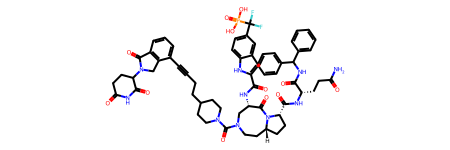

NC(=O)c1c(-c2ccc(Oc3ccccc3)cc2)nn2c1NCC[C@H]2C1CCN(C(=O)CCCc2ccc(NC(=O)CNc3ccc4c(c3)C(=O)N(C3CCC(=O)NC3=O)C4=O)cc2)CC1


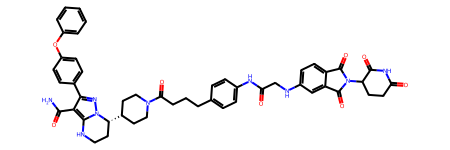

COc1cc(N2CCC(N3CCN(C(=O)CNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)CC3)CC2)ccc1Nc1ncc(Cl)c(Nc2ccccc2P(C)(C)=O)n1


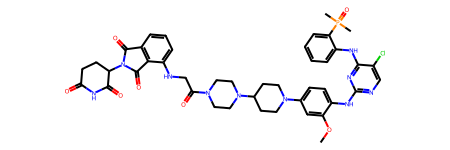

Cc1cccc(-c2cnc(Nc3cnn(C4CCN(C5CCC6(CC5)CCN(C(=O)c5ccc7c(c5)CN(C5CCC(=O)NC5=O)C7=O)CC6)CC4)c3)c3nccn23)c1


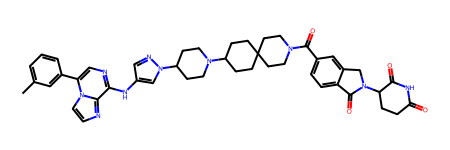

C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCNC(=O)c6ccc(NC(=O)[C@@H]7N[C@@H](CC(C)(C)C)[C@](C#N)(c8ccc(Cl)cc8F)[C@H]7c7cccc(Cl)c7F)c(OC)c6)CC5)cc4OC)nc32)c1


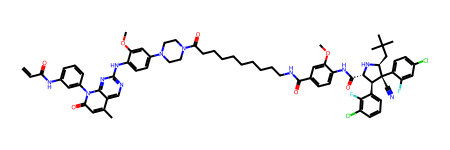

Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)N[C@@H](CC(=O)N2CCC(C#Cc3ccc(C(=O)N[C@H]4C(C)(C)[C@H](Oc5ccc(C#N)c(Cl)c5)C4(C)C)cc3)CC2)c2ccc(C#N)cc2)C(C)C)on1


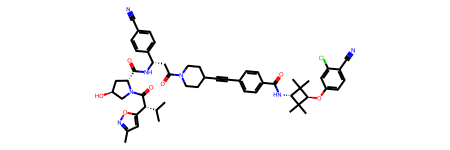

Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCOCCOCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)C(C)(C)C)cc1


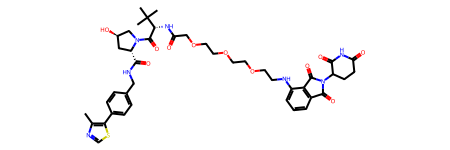

CS(=O)(=O)N1CCc2cccc(Nc3nc(Nc4ccc(N5CCC(N6CCN(CCC7CCN(c8ccc(C9CCC(=O)NC9=O)cc8)CC7)CC6)CC5)c(F)c4)nc4[nH]ccc34)c21


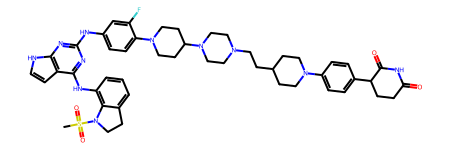

Cc1ccc(F)c(S(=O)(=O)Nc2ccc(-c3nc(OC[C@H]4CN(CCCCCCOCCOCCOCCOCC(=O)N[C@H](C(=O)N5C[C@H](O)C[C@H]5C(=O)NCc5ccc(-c6scnc6C)cc5)C(C)(C)C)CCO4)c4cn[nH]c4n3)cc2)c1


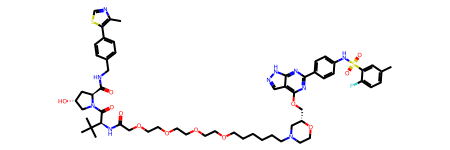

Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)N1CCN(CC(=O)NCCCCCOc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)CC1)c1nnc(C)n1-2


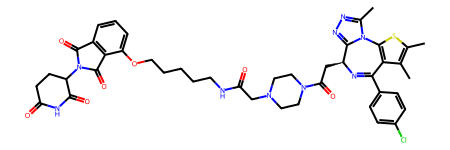

CS(=O)(=O)N1CCc2cccc(Nc3nc(Nc4ccc(N5CCC(N6CCN(CCc7cc(F)c(C8CCC(=O)NC8=O)c(F)c7)CC6)CC5)c(F)c4)nc4[nH]ccc34)c21


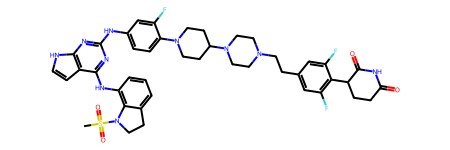

In [38]:
df = tack_w_preds_w_scores[tack_w_preds_w_scores['PROTAC-Splitter_Number_of_Warnings'] == 0]

for i, row in df.sample(n=20)['SMILES'].drop_duplicates().reset_index().iterrows():
    print(row['SMILES'])
    display(Chem.MolFromSmiles(row['SMILES']))
    if i > 20:
        break